# Exploratory Data Anlysis

#### Melakukan exploratory data analysis (EDA) untuk mendapatkan insight dari data 

##### Kategori: Menemukan Pola (Finding Patterns)
###### Tujuannya adalah memahami tren pasar event untuk mengoptimalkan kurasi pada portal Teemo.  
###### Pertanyaan Bisnis: "Bidang utama (bidang_utama) apa yang memiliki frekuensi penyelenggaraan event dan rata-rata jumlah peserta terbanyak dalam data tahun 2024-2026 untuk menentukan prioritas kategori di halaman utama?"  
###### Analisis: Membantu tim menentukan kategori mana yang paling populer sehingga fitur pencarian dan filter bisa lebih relevan bagi pengguna.  

##### Kategori: Menemukan Hubungan (Finding Connections)
###### Tujuannya adalah menganalisis faktor penarik minat peserta agar Teemo dapat memberikan masukan kepada penyelenggara event.  ###### Pertanyaan Bisnis: "Seberapa besar korelasi antara nominal hadiah (hadiah) dengan jumlah pendaftar (jumlah_peserta) pada kategori 'Tech & IT' guna memberikan rekomendasi strategi bagi penyelenggara dalam menarik minat calon peserta?"  
###### Analisis: Jika korelasi rendah, Teemo bisa menyarankan penyelenggara untuk lebih fokus pada branding tema atau kemudahan kolaborasi daripada hanya besaran uang.  

##### Kategori: Mengategorikan Berbagai Hal (Categorizing Things
###### Tujuannya adalah mengoptimalkan sistem rekomendasi collaborative filtering yang sedang dibangun.  
###### Pertanyaan Bisnis: "Berdasarkan kemiripan tema (tema) dan bidang, bagaimana pengelompokan event yang paling optimal untuk meningkatkan akurasi sistem rekomendasi personal bagi pengguna?"
###### Analisis: Data hasil pengelompokan ini akan menjadi dasar bagi AI Engineer dalam merancang model rekomendasi yang lebih cerdas.  

##### Kategori: Menemukan Sesuatu yang Tidak Biasa (Finding Unusual Things)Tujuannya adalah mengidentifikasi peluang atau hambatan tersembunyi.  
###### Pertanyaan Bisnis: "Apakah terdapat event dengan jumlah peserta tinggi namun diselenggarakan oleh 'Penyelenggara Independen', dan tema apa yang mereka usung yang membedakannya dari institusi besar?"  
###### Analisis: Mengidentifikasi tren 'akar rumput' yang bisa dijadikan peluang konten eksklusif bagi Teemo.  

##### Kategori: Membuat Prediksi (Making Predictions)
###### Tujuannya adalah perencanaan kampanye pemasaran fitur "Rooms" kolaborasi.  
###### Pertanyaan Bisnis: "Berdasarkan riwayat tanggal tenggat pendaftaran (deadline_date), kapan periode puncak (peak season) event kolaboratif terjadi sehingga tim pemasaran dapat meningkatkan kampanye fitur 'Rooms' satu bulan sebelumnya?" 
###### Analisis: Memastikan fitur kolaborasi Teemo digunakan pada waktu yang paling efektif ketika minat pencarian tim sedang tinggi.  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# LANGKAH

### A. Eksplorasi Bidang Utama (Menemukan Pola)
#### Kami menganalisis distribusi penyelenggaraan event dan minat peserta untuk menentukan prioritas kategori di portal Teemo.

In [2]:
df = pd.read_csv('dataset_lomba_siap_analisis.csv')
df_clean = df[df['jumlah_peserta'] >= 0].copy()
bidang_stats = df_clean.groupby('bidang_utama', observed=True).agg(
    jumlah_event=('nama_lomba', 'count'),
    rata_rata_peserta=('jumlah_peserta', 'mean')
).sort_values(by='jumlah_event', ascending=False)

#Menampilkan hasil statistik untuk verifikasi insight
print("Statistik per Bidang Utama:")
print(bidang_stats)

plt.tight_layout()
plt.show()

Statistik per Bidang Utama:
                     jumlah_event  rata_rata_peserta
bidang_utama                                        
Bisnis & Ekonomi              239        2109.171548
Kesehatan                     237        1979.244726
Tech & IT                     232        1831.767241
Sosial & Lingkungan           210        2071.685714
Lainnya                        10        2129.200000


<Figure size 640x480 with 0 Axes>

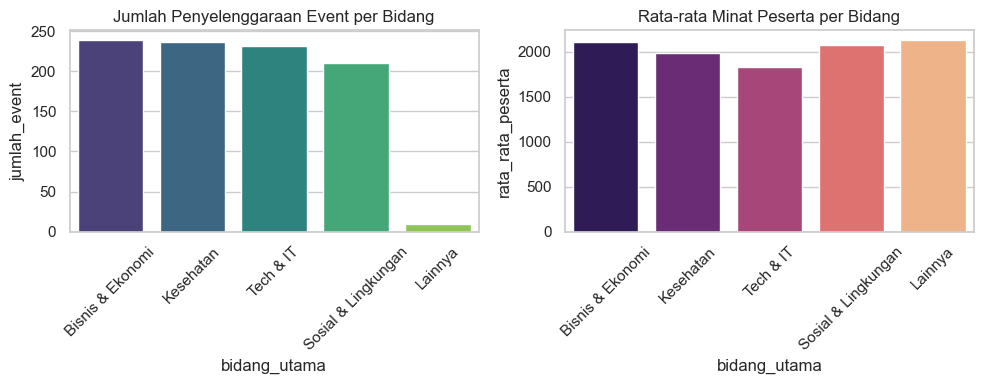

In [3]:
#Visualisasi Data menggunakan Seaborn
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#Visualisasi Frekuensi Event (Suplai)
sns.barplot(ax=axes[0], x=bidang_stats.index, y=bidang_stats['jumlah_event'], palette='viridis')
axes[0].set_title('Jumlah Penyelenggaraan Event per Bidang')
axes[0].tick_params(axis='x', rotation=45)

#Visualisasi Rata-rata Peserta (Minat/Permintaan)
sns.barplot(ax=axes[1], x=bidang_stats.index, y=bidang_stats['rata_rata_peserta'], palette='magma')
axes[1].set_title('Rata-rata Minat Peserta per Bidang')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Insight : 
1. Dominasi kategori berada di Bisnis & Ekonomi. Kategori ini tidak hanya memiliki jumlah event terbanyak (239 event), tetapi juga menarik minat peserta rata-rata paling tinggi (~2.109 orang).  
2. Untuk kategori sosial, Meskipun secara frekuensi berada di urutan keempat, minat pesertanya sangat tinggi (~2.071 orang) dan berada di urutan ke-empat juga, menunjukkan bahwa pengguna Teemo sangat peduli pada isu-isu berdampak sosial.  
3. untuk kategori Kesehatan & IT. Memiliki suplai event yang sangat bersaing (masing-masing 237 dan 232 event), menjadikannya pilar konten utama bagi platform Teemo. 

Selanjutnya kami ingin mengenai analisis hubungan (korelasi) antara nominal hadiah dengan jumlah peserta, khusus untuk bidang "Tech & IT".

Nilai Korelasi Pearson: -0.0166


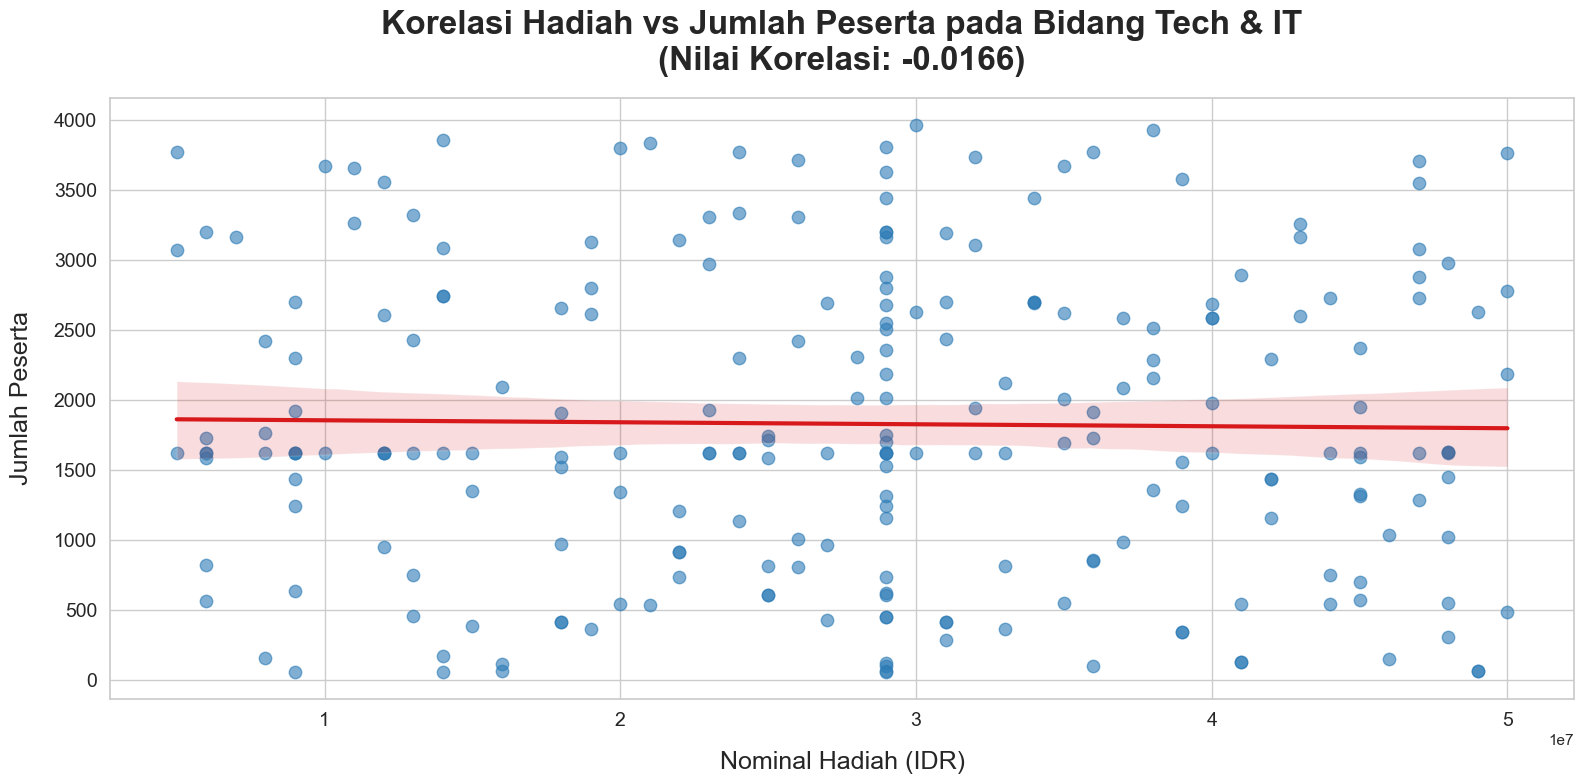

In [5]:
df = pd.read_csv('dataset_lomba_siap_analisis.csv')

df_clean = df[df['jumlah_peserta'] >= 0].copy()

df_tech = df_clean[df_clean['bidang_utama'] == 'Tech & IT'].copy()

# Mendekati 1 = korelasi positif kuat, mendekati -1 = korelasi negatif kuat, sekitar 0 = tidak ada korelasi
korelasi = df_tech['hadiah'].corr(df_tech['jumlah_peserta'])
print(f"Nilai Korelasi Pearson: {korelasi:.4f}")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8)) 

ax = sns.regplot(
    data=df_tech, 
    x='hadiah', 
    y='jumlah_peserta', 
    scatter_kws={'alpha': 0.6, 's': 80, 'color': '#2c7bb6'}, # Titik biru transparan
    line_kws={'color': '#d7191c', 'linewidth': 3}             # Garis regresi merah tebal
)

plt.title(f'Korelasi Hadiah vs Jumlah Peserta pada Bidang Tech & IT\n(Nilai Korelasi: {korelasi:.4f})', 
          fontsize=24, pad=20, fontweight='bold')
plt.xlabel('Nominal Hadiah (IDR)', fontsize=18, labelpad=15)
plt.ylabel('Jumlah Peserta', fontsize=18, labelpad=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

#### insight: 
1. Fakta Data
- Garis merah yang mendatar sempurna dan titik-titik (event) yang menyebar secara acak membuktikan bahwa besaran nominal hadiah bukanlah faktor penentu atau magnet utama bagi peserta untuk mendaftar lomba di bidang Tech & IT.  
- Terlihat jelas di grafik bahwa lomba dengan hadiah kecil (di bawah Rp 10 juta) bisa memiliki jumlah peserta yang sama tingginya (mencapai 3.000+ peserta) dengan lomba berhadiah sangat besar (mendekati Rp 50 juta).  

2. Mengapa Ini Terjadi? (Konteks Perilaku Peserta)
Di ekosistem teknologi (seperti hackathon, ideathon, atau coding camp), peserta umumnya lebih mengejar nilai pengalaman, kesempatan membangun portofolio nyata, networking, atau tertarik pada tantangan tema spesifik (misalnya menyelesaikan masalah dengan AI atau Blockchain). Hadiah uang hanyalah bonus, bukan motivasi primer.

3. Aksi Strategis untuk Teemo 
- Saat Teemo bekerja sama dengan penyelenggara event, kami dapat menggunakan data ini sebagai senjata. Kami bisa menyarankan penyelenggara agar tidak memaksakan atau menghabiskan anggaran hanya untuk hadiah uang tunai. Dana tersebut akan lebih efektif jika dialokasikan untuk kualitas acara, juri profesional, atau branding tema yang kuat.  
- Mengingat peserta lebih mencari kolaborasi dan pengalaman, fitur Rooms yang Teemo kembangkan menjadi solusi yang sangat relevan dan tepat sasaran. Strategi pemasaran Teemo harus berfokus pada pesan: "Temukan rekan tim yang sefrekuensi dan bangun portofoliomu di sini", karena itulah yang sebenarnya dicari.

Selanjutnya kami akan menganalisis Tema Populer. Ini akan membantu tim  AI Engineer dalam memahami pengelompokan alami event untuk sistem Collaborative Filtering.

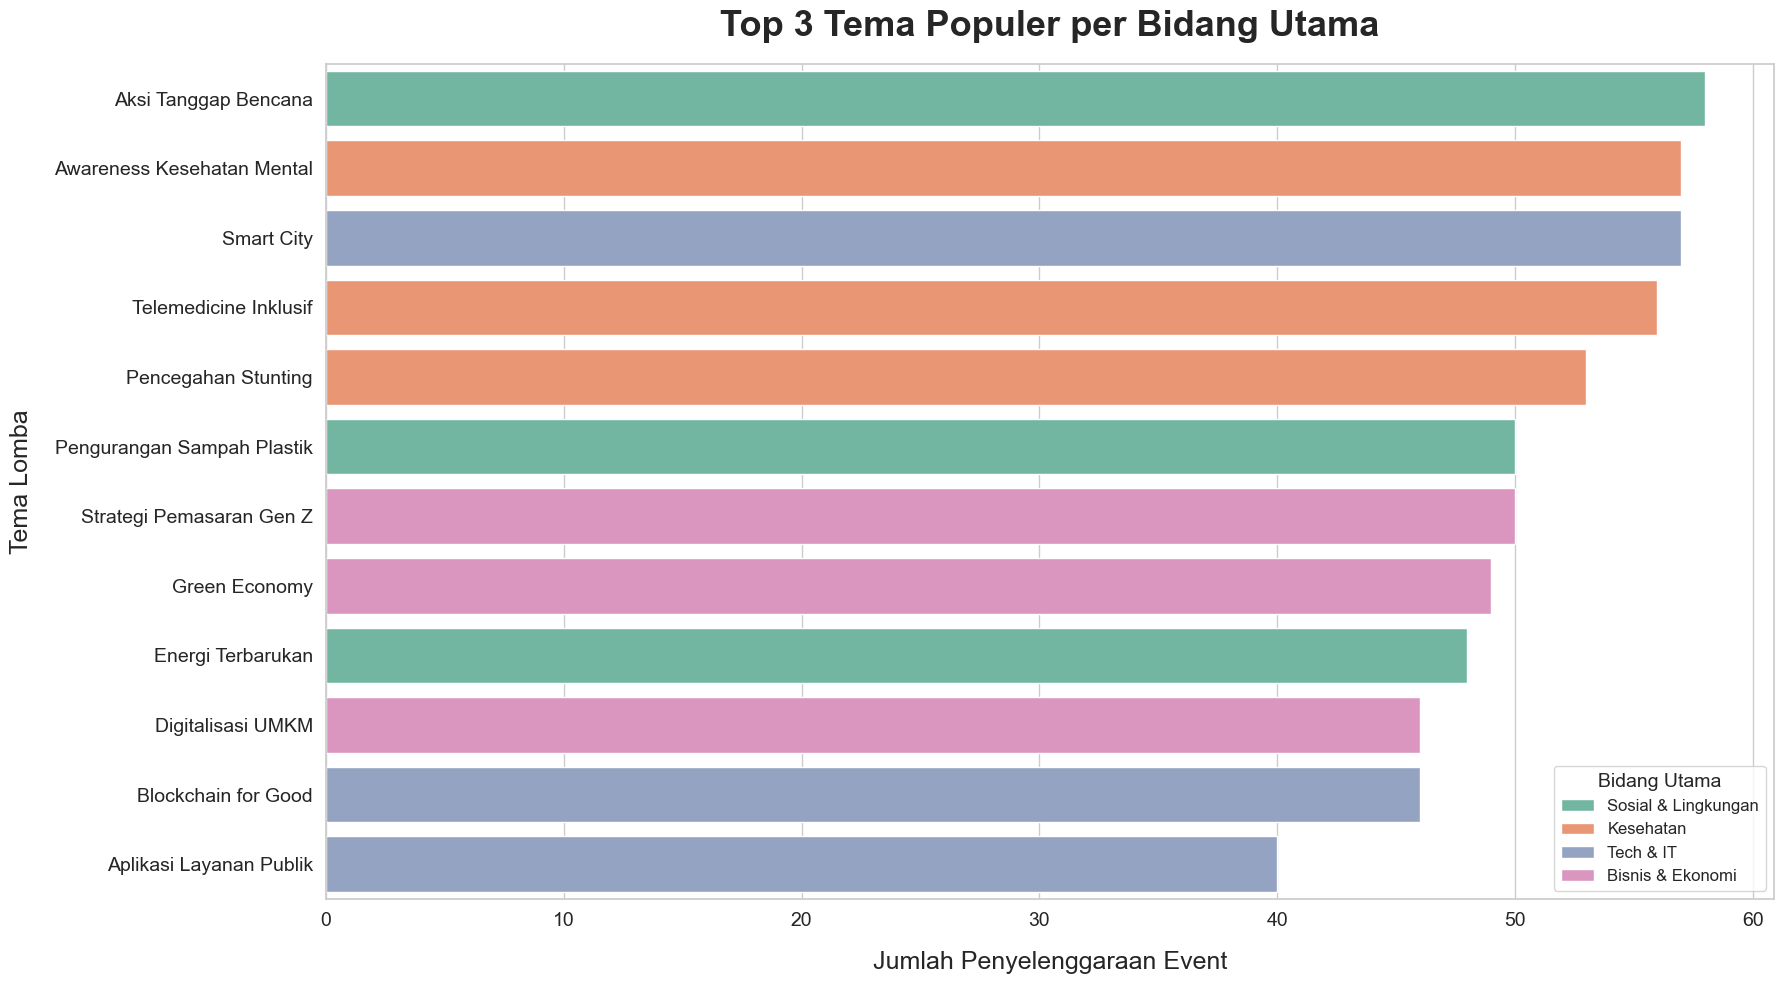

In [6]:
df = pd.read_csv('dataset_lomba_siap_analisis.csv')
df_clean = df[df['jumlah_peserta'] >= 0].copy()

theme_counts = df_clean.groupby(['bidang_utama', 'tema'], observed=True).size().reset_index(name='jumlah_event')
top_themes = theme_counts.sort_values(['bidang_utama', 'jumlah_event'], ascending=[True, False]).groupby('bidang_utama').head(3)

major_fields = ['Bisnis & Ekonomi', 'Kesehatan', 'Tech & IT', 'Sosial & Lingkungan']
top_themes_major = top_themes[top_themes['bidang_utama'].isin(major_fields)].copy()
top_themes_major = top_themes_major.sort_values('jumlah_event', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 10))

ax = sns.barplot(
    data=top_themes_major, 
    y='tema', 
    x='jumlah_event', 
    hue='bidang_utama',
    dodge=False, # Agar bar tidak bertumpuk/terbagi
    palette='Set2'
)

plt.title('Top 3 Tema Populer per Bidang Utama', fontsize=26, pad=20, fontweight='bold')
plt.xlabel('Jumlah Penyelenggaraan Event', fontsize=18, labelpad=15)
plt.ylabel('Tema Lomba', fontsize=18, labelpad=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(title='Bidang Utama', title_fontsize='14', fontsize='12', loc='lower right')

plt.tight_layout()
plt.show()

#### Insight:
- Meskipun dipisahkan berdasarkan bidang_utama, kita bisa melihat irisan (intersection) yang menarik. Misalnya, di bidang Tech & IT, tema tertinggi adalah Smart City (57) dan Aplikasi Layanan Publik (40). Sementara di Bisnis & Ekonomi, tema tingginya adalah Digitalisasi UMKM (46) dan Green Economy (49).  

- Aksi untuk AI Engineer (Collaborative Filtering):
Karena kammi ingin merancang collaborative filtering, sistem rekomendasinya tidak boleh kaku hanya berdasarkan kategori. Sistem harus mengenali kedekatan antar-tema (anchor points). Jika pengguna A sering mengikuti lomba bertema Digitalisasi UMKM (Bisnis), sistem harus merekomendasikan pengguna A ini kepada developer yang tertarik pada Aplikasi Layanan Publik (Tech). Di sanalah letak kekuatan matchmaking Teemo untuk menghubungkan lintas-kemampuan (Bisnis + Tech).

Selanjutnay kami membahas mengenai penyelenggara independen. Di sini, kita akan memfilter data khusus untuk menemukan event-event "akar rumput" yang paling sukses menarik massa besar.

                             nama_lomba                        tema  \
51             Ideathon Balikpapan 2024                  Smart City   
563      Preneur Olympiad Makassar 2025           Digitalisasi UMKM   
554  Festival Pitching Summit Samarinda     Umum - Bisnis & Ekonomi   
183          med inno samarinda 2026     Awareness Kesehatan Mental   
350             Aksi Baik Makassar 2024        Aksi Tanggap Bencana   

     jumlah_peserta  
51             3932  
563            3924  
554            3887  
183            3857  
350            3749  


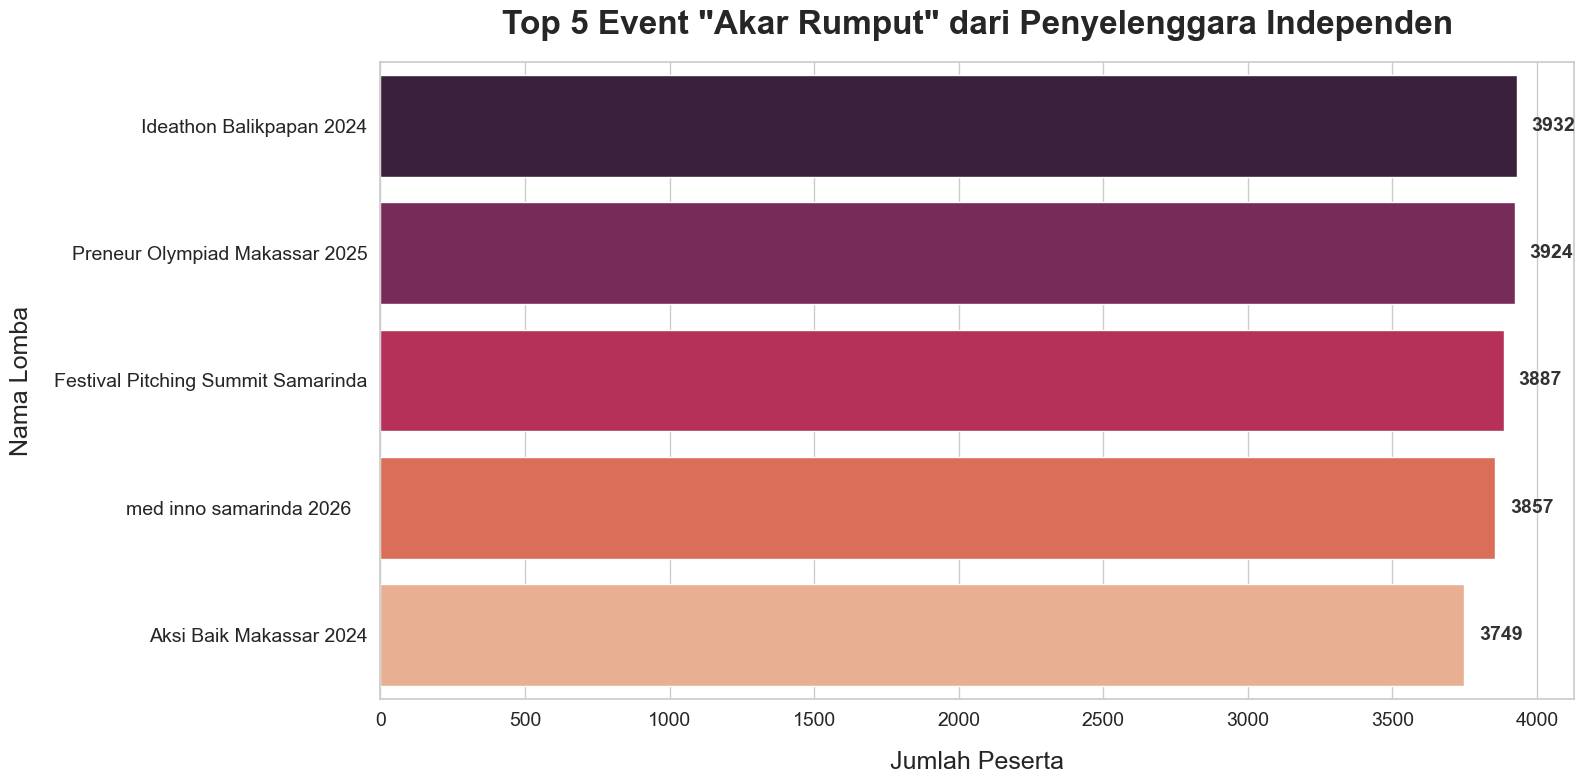

In [9]:
df = pd.read_csv('dataset_lomba_siap_analisis.csv')
df_clean = df[df['jumlah_peserta'] >= 0].copy()

df_indie = df_clean[df_clean['penyelenggara'] == 'Penyelenggara Independen']

top_indie = df_indie.sort_values(by='jumlah_peserta', ascending=False).head(5)

print(top_indie[['nama_lomba', 'tema', 'jumlah_peserta']])


sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))

ax = sns.barplot(
    data=top_indie, 
    x='jumlah_peserta', 
    y='nama_lomba', 
    palette='rocket'
)

plt.title('Top 5 Event "Akar Rumput" dari Penyelenggara Independen', fontsize=24, pad=20, fontweight='bold')
plt.xlabel('Jumlah Peserta', fontsize=18, labelpad=15)
plt.ylabel('Nama Lomba', fontsize=18, labelpad=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 50, p.get_y() + p.get_height() / 2, f'{int(width)}', 
             ha='left', va='center', fontsize=14, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

#### Insight:
- Dari hasil visualisasi di atas, terbukti bahwa Ideathon Balikpapan 2024 (3.932 peserta) dan Preneur Olympiad Makassar 2025 (3.924 peserta) menempati posisi teratas meskipun tanpa bendera institusi besar. Uniknya, event-event ini mengusung tema yang kuat (seperti Smart City dan Digitalisasi UMKM), membuktikan bahwa branding tema jauh lebih menjual daripada status institusional.  

- Event dengan partisipasi semasif ini harus dilindungi kredibilitasnya. Kami dapat mulai merancang sistem badge "Verified" bagi penyelenggara independen. Verifikasi ini bukan berdasarkan status hukum perusahaannya, melainkan berdasarkan riwayat success rate dan feedback dari peserta sebelumnya di dalam platform Teemo.

Selanjutnya yaitu mengenai prediksi Peak Season

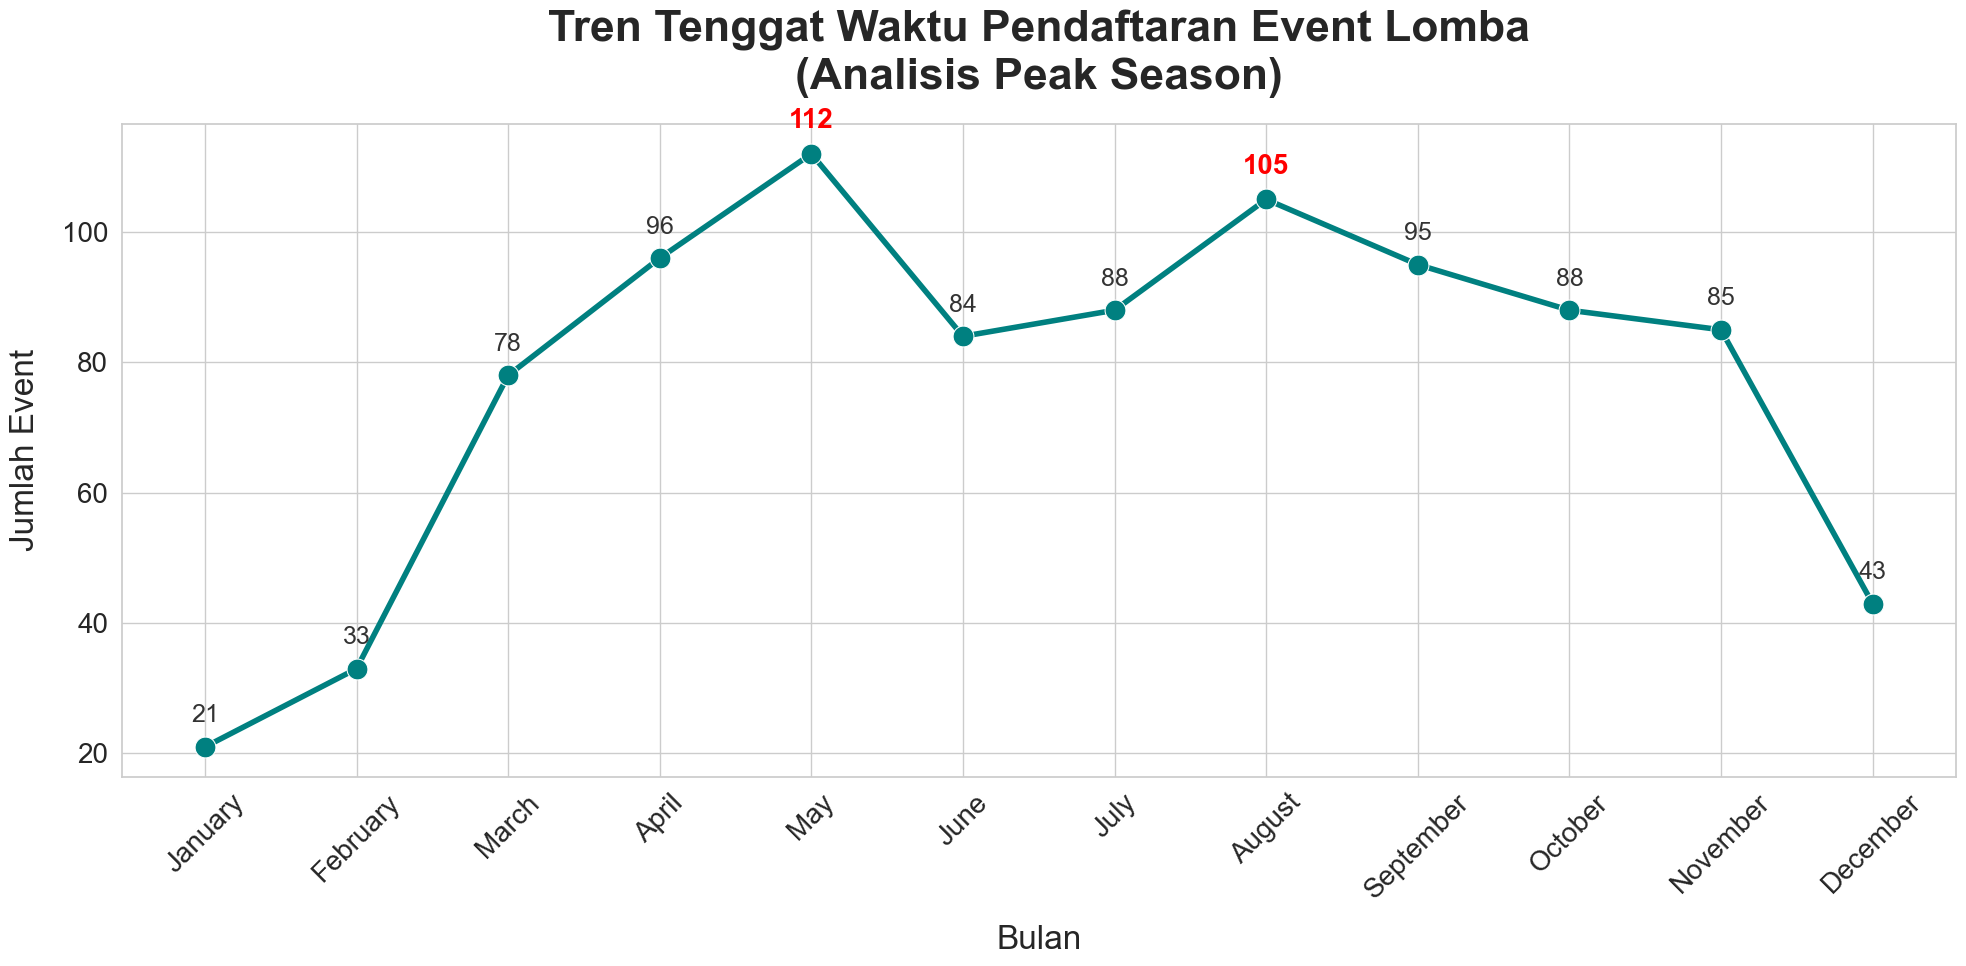

In [11]:
df = pd.read_csv('dataset_lomba_siap_analisis.csv')

df['deadline_date'] = pd.to_datetime(df['deadline_date'])

df_clean = df[df['jumlah_peserta'] >= 0].copy()

df_clean['bulan_tenggat'] = df_clean['deadline_date'].dt.month_name()
df_clean['bulan_num'] = df_clean['deadline_date'].dt.month

peak_season = df_clean.groupby(['bulan_num', 'bulan_tenggat']).size().reset_index(name='jumlah_event').sort_values('bulan_num')

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(20, 10))

ax = sns.lineplot(
    data=peak_season, 
    x='bulan_tenggat', 
    y='jumlah_event', 
    marker='o',          
    color='#008080',     
    linewidth=4,        
    markersize=15        
)

plt.title('Tren Tenggat Waktu Pendaftaran Event Lomba\n(Analisis Peak Season)', fontsize=32, pad=25, fontweight='bold')
plt.xlabel('Bulan', fontsize=24, labelpad=15)
plt.ylabel('Jumlah Event', fontsize=24, labelpad=15)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=20)


for x, y in zip(range(len(peak_season)), peak_season['jumlah_event']):
    if y > 100:
        plt.text(x, y + 3, f'{y}', ha='center', va='bottom', fontsize=20, fontweight='bold', color='red')
    else:
        plt.text(x, y + 3, f'{y}', ha='center', va='bottom', fontsize=18, color='#333333')

plt.tight_layout()
plt.show()

#### Insight:
- data dengan jelas memvalidasi bahwa lonjakan tenggat waktu (deadline) terjadi di pertengahan tahun, yaitu memuncak pada bulan Mei (112 event) dan Agustus (105 event). Titik terendah ada di awal dan akhir tahun (Januari dan Desember).  

- Fitur "Rooms" di Teemo berfungsi untuk mempertemukan orang-orang sebelum mendaftar lomba. Karena peserta butuh waktu berminggu-minggu untuk brainstorming dan menyamakan jadwal, kampanye fitur ini harus diledakkan 1 hingga 1,5 bulan sebelum puncak tenggat waktu, yaitu pada bulan April dan Juli. Di bulan-bulan tersebut, kepanikan (urgency) peserta mencari rekan tim sedang sangat tinggi.